<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_100_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention 예제 1:

In [ ]:
# ==========================================
# 한글 폰트 설치 및 설정 (Colab)
# ==========================================
import matplotlib.pyplot as plt

!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

In [ ]:
# =============================================================
# Attention 직관적으로 이해하기 (Transformer 설명 전 도입용 예제)
# TensorFlow / Keras 버전, Google Colab에서 실행 가능
# =============================================================

import tensorflow as tf
import numpy as np

tf.random.set_seed(0)

# ---- 1. 예제 문장 준비 ----
# "나는 오늘 아침에 커피를 마셨다" 를 단어 단위로 쪼갠다고 가정
words = ["나는", "오늘", "아침에", "커피를", "마셨다"]
n = len(words)
d = 8  # 임베딩 차원 (설명이 목적이므로 작게 설정)

# 각 단어를 임의의 벡터로 표현 (실제로는 학습된 임베딩)
X = tf.random.normal((n, d))

print("1단계: 각 단어가 벡터로 표현됨")
print(f"  단어 개수: {n}, 벡터 차원: {d}")
print(f"  X.shape = {X.shape}\n")

1단계: 각 단어가 벡터로 표현됨
  단어 개수: 5, 벡터 차원: 8
  X.shape = (5, 8)



In [ ]:
# ---- 2. Query, Key, Value 만들기 ----
# 실제 Transformer는 학습되는 선형변환(W_q, W_k, W_v)을 사용하지만,
# 여기서는 "각 단어가 질문(Q)과 답변 후보(K, V)를 동시에 가진다"는
# 개념만 보여주기 위해 간단한 Dense 레이어를 하나씩 사용한다.

W_q = tf.keras.layers.Dense(d, use_bias=False)   # 행렬 곱셈(X@W)
W_k = tf.keras.layers.Dense(d, use_bias=False)
W_v = tf.keras.layers.Dense(d, use_bias=False)

Q = W_q(X)   # "나는 무엇을 찾고 있는가"
K = W_k(X)   # "나는 무엇을 갖고 있는가"
V = W_v(X)   # "실제로 전달할 정보"

print("2단계: Query(질문), Key(단서), Value(정보)를 만듦")
print(f"  Q, K, V shape 모두 {tuple(Q.shape)}\n")


2단계: Query(질문), Key(단서), Value(정보)를 만듦
  Q, K, V shape 모두 (5, 8)



In [ ]:
scores = tf.matmul(Q, K, transpose_b=True) / np.sqrt(d)   # (n, n) 행렬

print("3단계: 단어 쌍마다 유사도 점수 계산 (Q·K)")
print(f"  scores.shape = {tuple(scores.shape)}  (5x5, 단어 x 단어)\n")
tf.round(scores * 100) / 100

3단계: 단어 쌍마다 유사도 점수 계산 (Q·K)
  scores.shape = (5, 5)  (5x5, 단어 x 단어)



<tf.Tensor: shape=(5, 5), dtype=float32, numpy=
array([[-1.05,  0.33, -0.79,  0.06, -0.15],
       [-0.3 , -0.65,  0.78,  0.39, -0.7 ],
       [ 0.03, -0.19,  0.29,  0.12, -0.04],
       [-0.67,  0.39, -1.27,  0.29, -0.05],
       [-1.44,  0.06, -0.65,  0.35, -0.39]], dtype=float32)>

In [ ]:
# ---- 4. Softmax로 "주목 비율"로 변환 ----
attn_weights = tf.nn.softmax(scores, axis=-1)

print("4단계: Softmax로 각 행의 합이 1이 되는 '주목 비율'로 변환")
print("  예) '커피를' 행이 다른 단어에 주는 attention 비율:")
coffee_idx = words.index("커피를")

for w, p in zip(words, attn_weights[coffee_idx]):
    print(f"    {w}: {p.numpy():.3f}")
print()


4단계: Softmax로 각 행의 합이 1이 되는 '주목 비율'로 변환
  예) '커피를' 행이 다른 단어에 주는 attention 비율:
    나는: 0.112
    오늘: 0.325
    아침에: 0.062
    커피를: 0.293
    마셨다: 0.208



In [ ]:
# ---- 5. 가중합으로 최종 출력 만들기 ----
output = tf.matmul(attn_weights, V)

print("5단계: 가중치만큼 Value를 섞어서 최종 벡터 생성")
print(f"  output.shape = {tuple(output.shape)}  (입력과 동일한 shape)")
print("  → '커피를'의 새 벡터는 자기 자신 + 문맥 속 다른 단어 정보가 섞인 결과\n")


5단계: 가중치만큼 Value를 섞어서 최종 벡터 생성
  output.shape = (5, 8)  (입력과 동일한 shape)
  → '커피를'의 새 벡터는 자기 자신 + 문맥 속 다른 단어 정보가 섞인 결과



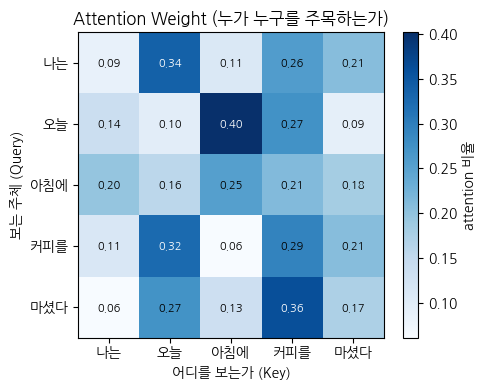

In [ ]:
# ---- 6. 히트맵으로 시각화 (모든 단어에 대해) ----
attn_np = attn_weights.numpy()

plt.figure(figsize=(5, 4))
plt.imshow(attn_np, cmap="Blues")
plt.xticks(range(n), words)
plt.yticks(range(n), words)
plt.xlabel("어디를 보는가 (Key)")
plt.ylabel("보는 주체 (Query)")
plt.title("Attention Weight (누가 누구를 주목하는가)")
plt.colorbar(label="attention 비율")
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{attn_np[i, j]:.2f}",
                  ha="center", va="center", fontsize=8,
                  color="white" if attn_np[i, j] > 0.3 else "black")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150)
plt.show()

- 만약 Q = K = X (즉 raw 벡터를 그대로 내적) 라면, 자기 자신과의 내적(자기 norm 제곱)이 보통 가장 크기 때문에 대각선이 최댓값이 되는 경우가 많다. 하지만 이 코드에서는 Q와 K가 서로 다른 선형변환(W_q, W_k)을 거친 결과이다.
  - Q = W_q(X)   # X를 W_q로 투영한 것
  - K = W_k(X)   # X를 W_k로 투영한 것
- W_q와 W_k가 다르기 때문에, Q[i] · K[i] (자기 자신의 Q와 K의 내적)가 Q[i] · K[j] (다른 단어와의 내적)보다 크다는 보장이 전혀 없다.
- 이게 바로 Transformer가 self-attention에서 굳이 Q, K, V를 따로 학습시키는 이유 중 하나이다 — "나 자신에게 가장 주목한다"는 당연한 결과를 깨고, 문맥에 따라 다른 단어에 더 주목하도록 학습 가능하게 만드는 것이다.

# Attention 예제 2:
- Attention의 최종 출력은 문장 전체의 의미를 흡수하여 각 단어마다 새롭게 재정의된 '문맥 반영 임베딩 벡터'이다.

In [ ]:
import numpy as np


def softmax(x):
    # 수치 안정성을 위해 np.max를 차감하고 지수승
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))  # 가장 마지막 차원, 차원 유지
    return e_x / np.sum(e_x, axis=-1, keepdims=True)


# 1. 문장 정의: "The river bank was covered with grass" (6개 단어)
words = ["The", "river", "bank", "was", "covered", "grass"]
seq_len = len(words)
d_model = 4  # 이해를 돕기 위해 각 단어의 임베딩 차원을 4차원으로 설정

# 임의의 단어 임베딩 벡터 (실제로는 Word2Vec이나 학습된 Embedding Layer 사용)
np.random.seed(42)
X = np.random.randn(seq_len, d_model)  # (6, 4) 행렬
print(X)

[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819]]


In [ ]:
# 2. Q, K, V를 만들기 위한 가중치 행렬 (W_q, W_k, W_v)
d_k = 5  # Q, K, V의 차원
W_q = np.random.randn(d_model, d_k)
W_k = np.random.randn(d_model, d_k)
W_v = np.random.randn(d_model, d_k)
print(W_q.shape,  W_k.shape,  W_v.shape)

(4, 5) (4, 5) (4, 5)


In [ ]:
# 3. Q, K, V 벡터 생성 (행렬 곱)
Q = np.dot(X, W_q)  # (6, 5)
K = np.dot(X, W_k)  # (6, 5)
V = np.dot(X, W_v)  # (6, 5)

# 4. Attention Score 계산 (Q x K^T)
# scaled dot-product attention: sqrt(d_k)로 나누어 상쇄
scores = np.dot(Q, K.T) / np.sqrt(d_k)  # (6, 6) 행렬

# 5. Attention Weights 계산 (Softmax)
attention_weights = softmax(scores)  # (6, 6) 각 행의 합은 1
print(attention_weights.round(2)*100/100)

[[0.41 0.55 0.02 0.01 0.01 0.  ]
 [0.61 0.38 0.   0.   0.   0.  ]
 [0.01 0.01 0.08 0.39 0.21 0.31]
 [0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.02 0.08 0.1  0.8 ]
 [0.1  0.03 0.05 0.03 0.02 0.77]]


- attention_weights 의미: 특정 단어가 문장 안의 다른 단어들을 바라볼 때 쏟는 관심(시선)의 비율
  - 문맥 파악의 기준: bank가 '강둑'인지 '은행'인지 결정짓는 '스위치' 역할을 한다. 주변에 river가 있을 때 river 쪽 가중치를 높게 끌어올려 주는 것이 핵심이다.
  - 즉, 새롭게 만들어질 단어의 의미(Output)에 문장 안의 각 단어가 가진 정보(Value)가 몇 %씩 반영되었는지를 보여주는 '조합 비율(혼합 비율)'이다.

In [ ]:
# 6. 최종 Value와의 혼합 (Weighted Sum)
output = np.dot(attention_weights, V)  # (6, 5)
print(output)

[[-4.7316786   0.69051386  0.1649187   1.2304428  -0.69733601]
 [-4.75962059  0.77622812  0.23555262  1.72894611 -0.74299692]
 [ 4.87430138 -0.33215117 -1.52982618 -0.84499559 -0.57159158]
 [ 3.9912774   2.27394525 -0.95550612 -0.64723503  0.92133941]
 [ 4.2068415   1.51308827 -1.03001478 -0.80988298  0.60055877]
 [ 2.80413015  1.72847208 -0.7478046  -0.34151327  0.59611538]]


- output 의 의미: 주변 단어들과의 연관성(Attention Weight)을 반영하여, 각 단어의 의미를 훨씬 풍부하게 새로 만든 '문맥 반영 벡터(Contextualized Vector)'이다.
- Attention의 최종 출력($Output$)은 '문맥 정보가 융합된 새로운 형태의 단어 임베딩 벡터(Contextualized Embedding Vector)'이다.

In [ ]:
# ---------------------------------------------------------
# 결과 확인: 'bank' 단어(인덱스 2)가 주변 단어를 얼마나 참조하는가?
# ---------------------------------------------------------
bank_idx = words.index("bank")

print(f"=== '{words[bank_idx]}' 단어의 Attention 가중치 ===")

for target_word, weight in zip(words, attention_weights[bank_idx]):
    print(f"  -> {target_word:8s}: {weight:.4f} ({weight * 100:.1f}%)")

=== 'bank' 단어의 Attention 가중치 ===
  -> The     : 0.0094 (0.9%)
  -> river   : 0.0063 (0.6%)
  -> bank    : 0.0798 (8.0%)
  -> was     : 0.3879 (38.8%)
  -> covered : 0.2063 (20.6%)
  -> grass   : 0.3103 (31.0%)


In [ ]:
words

['The', 'river', 'bank', 'was', 'covered', 'grass']

In [ ]:
words.index("bank")

2

In [ ]:
attention_weights.round(2)*100/100

array([[0.41, 0.55, 0.02, 0.01, 0.01, 0.  ],
       [0.61, 0.38, 0.  , 0.  , 0.  , 0.  ],
       [0.01, 0.01, 0.08, 0.39, 0.21, 0.31],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.02, 0.08, 0.1 , 0.8 ],
       [0.1 , 0.03, 0.05, 0.03, 0.02, 0.77]])

In [ ]:
attention_weights[2]

array([0.00943868, 0.00632316, 0.07977029, 0.38786238, 0.20634492,
       0.31026057])

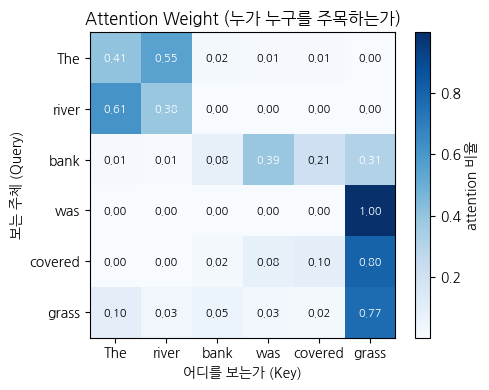

In [ ]:
attn_np = attention_weights

plt.figure(figsize=(5, 4))
plt.imshow(attn_np, cmap="Blues")
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)
plt.xlabel("어디를 보는가 (Key)")
plt.ylabel("보는 주체 (Query)")
plt.title("Attention Weight (누가 누구를 주목하는가)")
plt.colorbar(label="attention 비율")
for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attn_np[i, j]:.2f}",
                  ha="center", va="center", fontsize=8,
                  color="white" if attn_np[i, j] > 0.3 else "black")
plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150)
plt.show()

- 새로운 단어를 예측하는 3단계 과정
  - 1단계: 문맥 벡터(Context Vector) 추출: Attention 연산을 거쳐 문장 내 모든 위치의 관계가 반영된 최종 문맥 벡터가 만들어진다.
    - 예를 들어 "The boat is near the river [NEXT]" 라는 문장이 있다면, 마지막 위치에는 이전 단어들(boat, river 등)의 정보가 모두 융합된 문맥 벡터가 위치한다.
  - 2단계: 단어장(Vocabulary) 크기로 차원 확대 (Linear Layer): 이 문맥 벡터(예: 512차원)를 모델이 알고 있는 전체 단어장 크기(예: 30,000개 차원)로 뻥튀기해 주는 선형 변환(Linear Projection)을 거친다.
    - 이 결과로 나오는 30,000개의 숫자를 Logits(점수)라고 부른다.
    - 예: bank 점수 = 12.5, river 점수 = 2.1, apple 점수 = -4.3 ...
  - 3단계: Softmax로 확률 변환 후 단어 선택: 30,000개 점수에 Softmax를 적용하여 "다음 위치에 올 확률이 가장 높은 단어"를 뽑아낸다.
    - 점수가 가장 높은 bank(89% 확률)가 최종 예측 단어로 출력된다.

- GPT 같은 생성형 모델(Decoder)의 동작 방식: ChatGPT나 GPT 계열의 언어 모델이 글을 써 내려가는 방식이 바로 이 원리이다.
  - 1. 지금까지 나온 단어들의 문맥 벡터를 계산한다.
  - 2. 이 문맥 벡터를 바탕으로 다음 단어 하나를 예측하여 출력한다.
  - 3. 방금 새로 만든 단어를 기존 문장 뒤에 붙인다.
  - 4. 다시 문장 전체의 새로운 문맥 벡터를 구하고, 그다음 단어를 또 예측한다. (이 과정을 반복)

-----------------------------